# T04 面板 FE/RE -- 企业生产率的决定因素

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **论文题目** | 中国工业企业的全要素生产率估计 |
| **作者** | 鲁晓东, 连玉君 |
| **期刊** | 《经济学(季刊)》11(2), 541-558, 2012 |
| **核心问题** | 资本、劳动对产出弹性多大？FE还是RE更合适？ |
| **数据** | 中国工业企业数据库，Cobb-Douglas 生产函数 |

## 1. 研究设计

Cobb-Douglas:
$$\ln Y_{it} = \alpha + \beta_K \ln K_{it} + \beta_L \ln L_{it} + u_i + \varepsilon_{it}$$

关键问题：企业固定效应 $u_i$（管理能力等）是否与投入相关？
- 相关 -> 固定效应(FE/Within)
- 不相关 -> 随机效应(RE)更有效率
- 判断：Hausman 检验

## 2. 数学理论

**固定效应(Within)**：对个体去均值消除 $u_i$：
$$\tilde{y}_{it} = \beta_K \tilde{K}_{it} + \beta_L \tilde{L}_{it} + \tilde{\varepsilon}_{it}$$

**Hausman 统计量**：
$$H = (\hat{\beta}_{FE}-\hat{\beta}_{RE})^\top [\text{Var}(\hat{\beta}_{FE})-\text{Var}(\hat{\beta}_{RE})]^{-1}(\hat{\beta}_{FE}-\hat{\beta}_{RE}) \sim \chi^2_k$$

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.panel import PanelOLS, firm_panel_data

df = firm_panel_data(n_firms=100, n_years=8, seed=42)
print("列名:", list(df.columns))
print(df.describe().round(3))
df.head()


列名: ['firm_id', 'year', 'lnY', 'lnK', 'lnL', 'export']
       firm_id      year      lnY      lnK      lnL   export
count  800.000   800.000  800.000  800.000  800.000  800.000
mean    50.500  2013.500    3.372    3.957    3.479    0.290
std     28.884     2.293    0.751    1.011    0.818    0.454
min      1.000  2010.000    0.849    1.035    0.581    0.000
25%     25.750  2011.750    2.847    3.256    2.959    0.000
50%     50.500  2013.500    3.383    3.966    3.502    0.000
75%     75.250  2015.250    3.899    4.588    3.995    1.000
max    100.000  2017.000    5.204    7.179    5.831    1.000


,firm_id,year,lnY,lnK,lnL,export
0,1,2010,3.706295,3.621837,3.811753,1.0
1,1,2011,4.507666,5.299228,3.582043,1.0
2,1,2012,3.090346,3.643736,3.382046,0.0
3,1,2013,4.862462,4.737516,4.770621,1.0
4,1,2014,2.651431,3.066382,3.002234,0.0


## 4. 模型估计

In [2]:
from empirlab.traditional.panel import PanelOLS

x_cols = ['lnK', 'lnL']

# 固定效应
fe = PanelOLS(effect='fixed')
fe.fit(df, x_cols, 'lnY', 'firm_id', 'year')
print('=== 固定效应(Within) ===')
print(fe.summary_table().round(4))

=== 固定效应(Within) ===
             coef      se        t  p_value  ci_lower  ci_upper
parameter                                                      
lnK        0.3723  0.0120  31.0503      0.0    0.3487    0.3958
lnL        0.4843  0.0148  32.6870      0.0    0.4552    0.5134


In [3]:
# 随机效应
re = PanelOLS(effect='random')
re.fit(df, x_cols, 'lnY', 'firm_id', 'year')
print('=== 随机效应(GLS) ===')
print(re.summary_table().round(4))

=== 随机效应(GLS) ===
             coef      se        t  p_value  ci_lower  ci_upper
parameter                                                      
lnK        0.3735  0.0095  39.2149      0.0    0.3548    0.3922
lnL        0.4864  0.0112  43.4239      0.0    0.4644    0.5084


In [4]:
# Hausman 检验
h = PanelOLS.hausman_test(fe, re)
print(f'Hausman H = {h["H_stat"]:.3f},  df = {h["df"]},  p = {h["p_value"]:.4f}')
conclusion = '拒绝H0，使用固定效应' if h['p_value'] < 0.05 else '无法拒绝H0，RE更有效率'
print(f'结论: {conclusion}')

Hausman H = 0.075,  df = 2,  p = 0.9631
结论: 无法拒绝H0，RE更有效率


## 5. 结果解读

鲁晓东&连玉君(2012)发现中国制造业资本弹性约0.4、劳动弹性约0.5，规模报酬接近不变(CRTS)。
Hausman检验通常拒绝RE，说明企业固定效应与资本/劳动投入正相关。

In [5]:
# 规模报酬检验
returns_fe = sum(fe.coef_[:2])
returns_re = sum(re.coef_[:2])
print(f'规模报酬 FE: {returns_fe:.3f}  RE: {returns_re:.3f}')
print(f'FE 资本弹性: {fe.coef_[0]:.3f}, 劳动弹性: {fe.coef_[1]:.3f}')

规模报酬 FE: 0.857  RE: 0.860
FE 资本弹性: 0.372, 劳动弹性: 0.484


## 6. 可视化

/sessions/great-dazzling-ritchie/tmp/ipykernel_80/1528842091.py:9: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_80/1528842091.py:9: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_80/1528842091.py:9: UserWarning: Glyph 40 (() missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_80/1528842091.py:9: UserWarning: Glyph 110 (n) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_80/1528842091.py:9: UserWarning: Glyph 75 (K) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_80/1528842091.py:9: UserWarning: Glyph 41 ()) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-daz

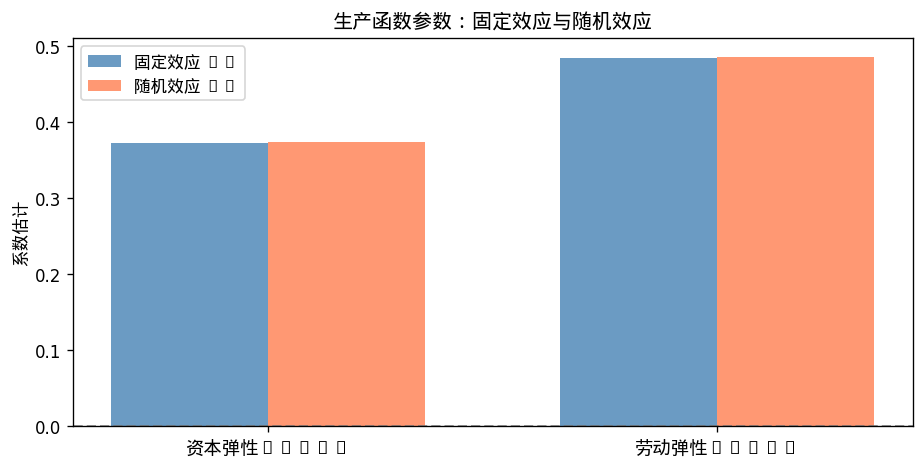

In [6]:
x = np.arange(len(x_cols)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, fe.coef_, w, label='固定效应 FE', color='steelblue', alpha=0.8)
ax.bar(x + w/2, re.coef_, w, label='随机效应 RE', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['资本弹性(lnK)', '劳动弹性(lnL)'], fontsize=11)
ax.set_ylabel('系数估计'); ax.set_title('生产函数参数：固定效应与随机效应')
ax.legend(); ax.axhline(0, ls='--', c='gray')
plt.tight_layout();show()